# Exercise 6

In [169]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset

In [170]:
img_size = 64
batch_size = 64

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = load_dataset("huggan/AFHQ", split="train")

def apply_transform(examples):
    examples["image"] = [transform(img.convert("RGB")) for img in examples["image"]]
    return examples

dataset.set_transform(apply_transform)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

## DiffusionUNet Model

### Model Architecture

In [ ]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        inv_freq = torch.exp(
            torch.arange(0, dim, 2, dtype=torch.float32) *
            -(torch.log(torch.tensor(10000.0)) / dim)
        )
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, t):
        pos_enc = t.unsqueeze(-1) * self.inv_freq.unsqueeze(0)
        pos_enc = torch.cat([torch.sin(pos_enc), torch.cos(pos_enc)], dim=-1)
        return pos_enc

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(32, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x))
        q, k, v = qkv.chunk(3, dim=1)
        
        q = q.view(B, C, -1).transpose(1, 2)
        k = k.view(B, C, -1)
        v = v.view(B, C, -1)
        
        attn = torch.softmax(torch.bmm(q, k) / (C ** 0.5), dim=-1)
        
        out = torch.bmm(v, attn.transpose(1, 2))
        out = out.view(B, C, H, W)
        return x + self.proj(out)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(32, in_ch)
        self.act1 = Swish()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_emb = nn.Sequential(
            Swish(),
            nn.Linear(time_dim, out_ch)
        )
        self.norm2 = nn.GroupNorm(32, out_ch)
        self.act2 = Swish()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        if in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, t):
        h = self.conv1(self.act1(self.norm1(x)))
        h += self.time_emb(t).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.shortcut(x)

class DiffusionUNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=64, time_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(base_channels),
            nn.Linear(base_channels, time_dim),
            Swish(),
            nn.Linear(time_dim, time_dim)
        )

        self.inc = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        self.down1 = ResBlock(base_channels, base_channels, time_dim)
        self.down2 = ResBlock(base_channels, base_channels * 2, time_dim)
        self.down3 = ResBlock(base_channels * 2, base_channels * 4, time_dim)
        self.attn1 = AttentionBlock(base_channels * 4)
        self.down4 = ResBlock(base_channels * 4, base_channels * 8, time_dim)
        self.attn2 = AttentionBlock(base_channels * 8)

        self.pool = nn.MaxPool2d(2)

        self.mid1 = ResBlock(base_channels * 8, base_channels * 8, time_dim)
        self.mid_attn = AttentionBlock(base_channels * 8)
        self.mid2 = ResBlock(base_channels * 8, base_channels * 8, time_dim)

        self.up1 = ResBlock(base_channels * 12, base_channels * 4, time_dim)
        self.up2 = ResBlock(base_channels * 6, base_channels * 2, time_dim)
        self.up3 = ResBlock(base_channels * 3, base_channels, time_dim)
        self.up4 = ResBlock(base_channels * 2, base_channels, time_dim)

        self.up_sample = nn.Upsample(scale_factor=2, mode='nearest')

        self.outc = nn.Sequential(
            nn.GroupNorm(32, base_channels),
            Swish(),
            nn.Conv2d(base_channels, in_channels, 3, padding=1)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x1 = self.inc(x)
        x2 = self.down1(x1, t_emb)
        x3 = self.down2(self.pool(x2), t_emb)
        
        x4 = self.down3(self.pool(x3), t_emb)
        x4 = self.attn1(x4)
        
        x5 = self.down4(self.pool(x4), t_emb)
        x5 = self.attn2(x5)

        h = self.mid1(x5, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)

        h = self.up_sample(h)
        h = torch.cat([h, x4], dim=1)
        h = self.up1(h, t_emb)

        h = self.up_sample(h)
        h = torch.cat([h, x3], dim=1)
        h = self.up2(h, t_emb)

        h = self.up_sample(h)
        h = torch.cat([h, x2], dim=1)
        h = self.up3(h, t_emb)

        h = torch.cat([h, x1], dim=1)
        h = self.up4(h, t_emb)

        return self.outc(h)

### DDPM (Denoising Diffusion Probabilistic Model)

In [175]:
class DDPM:
    def __init__(self, device, n_steps=1000, beta_start=1e-4, beta_end=0.02):
        self.n_steps = n_steps
        self.device = device
        self.beta = torch.linspace(beta_start, beta_end, n_steps).to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def noise_image(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1. - self.alpha_hat[t])[:, None, None, None]
        epsilon = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

    def sample(self, model, n, channels=3, size=64):
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, channels, size, size)).to(self.device)
            for i in reversed(range(self.n_steps)):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                
                if i > 0:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)
                    
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return x

## Training

In [ ]:
epochs = 200
model = DiffusionUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
ddpm = DDPM(device)
mse = nn.MSELoss()
from tqdm import tqdm

train_loss_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    progress_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")

    for batch in progress_train:
        images = batch["image"].to(device)
        t = torch.randint(0, ddpm.n_steps, (images.shape[0],)).to(device)
        
        noisy_images, noise = ddpm.noise_image(images, t)
        predicted_noise = model(noisy_images, t)
        loss = mse(noise, predicted_noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        progress_train.set_postfix({"loss": loss.item()})

    model.eval()
    val_loss = 0
    epoch_train_loss = train_loss / len(train_loader)
    train_loss_history.append(epoch_train_loss)

            
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f}")

Epoch 1/50:   0%|          | 0/253 [00:00<?, ?batch/s]

Epoch 1/50: 100%|██████████| 253/253 [00:30<00:00,  8.28batch/s, loss=0.0161]


Epoch 1/50 | Train Loss: 0.1060


Epoch 2/50: 100%|██████████| 253/253 [00:30<00:00,  8.21batch/s, loss=0.00918]


Epoch 2/50 | Train Loss: 0.0464


...

Epoch 48/50 | Train Loss: 0.0263


Epoch 49/50: 100%|██████████| 253/253 [00:32<00:00,  7.85batch/s, loss=0.00534]


Epoch 49/50 | Train Loss: 0.0255


Epoch 50/50: 100%|██████████| 253/253 [00:32<00:00,  7.85batch/s, loss=0.000482]

Epoch 50/50 | Train Loss: 0.0254


## Evaluation and Comparison

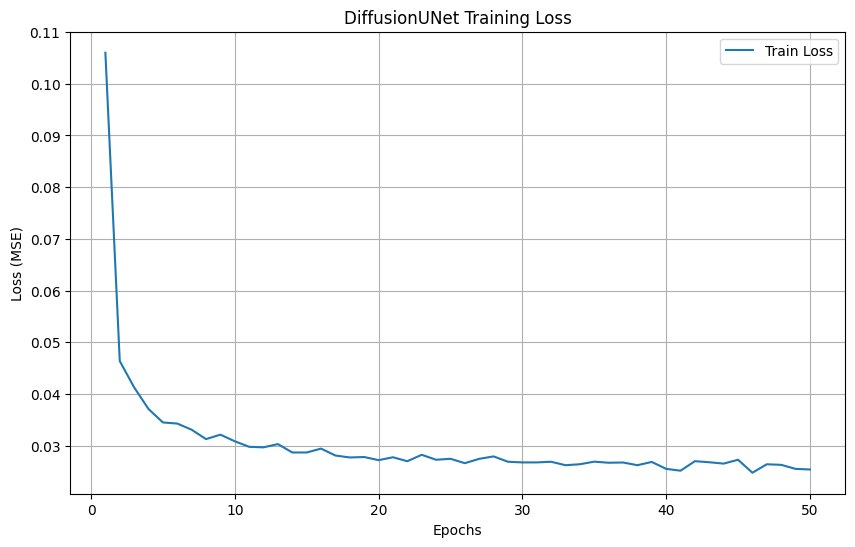

In [177]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("DiffusionUNet Training Loss")
plt.legend()
plt.grid(True)
plt.show()

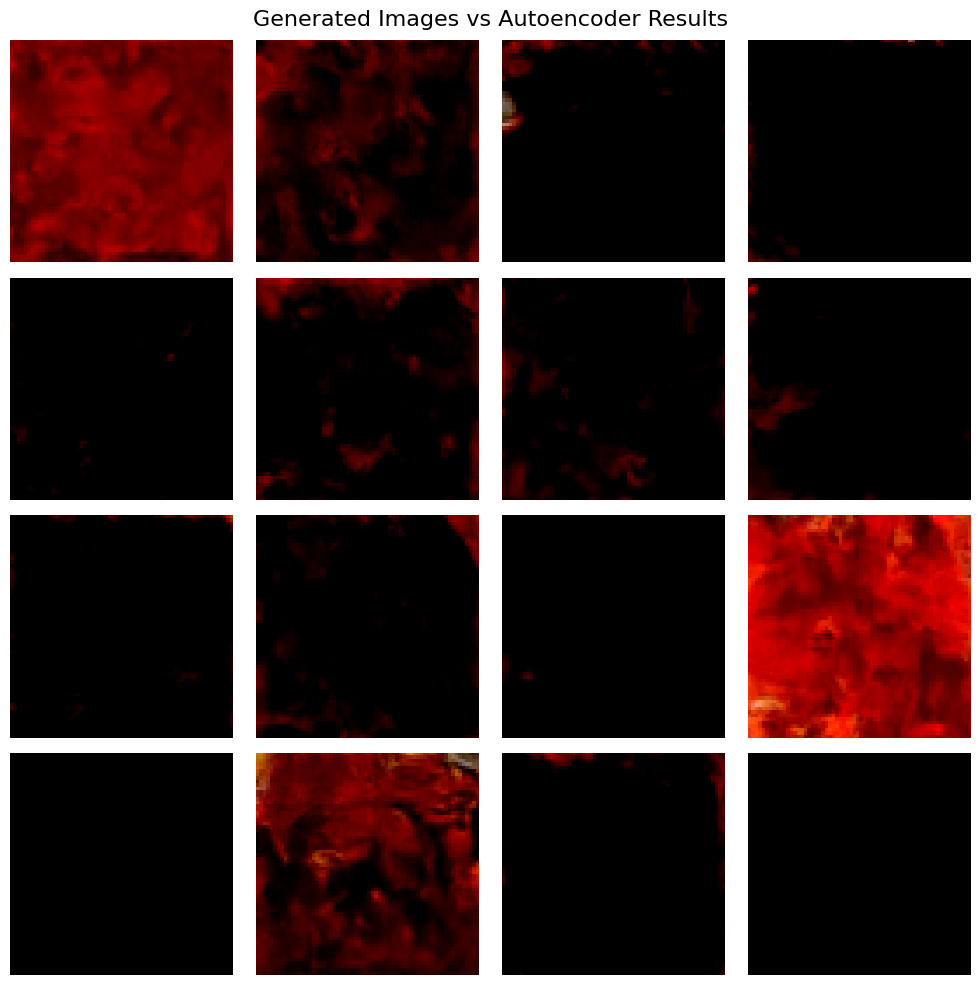

In [178]:
sampled_images = ddpm.sample(model, n=16, size=img_size)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    img = sampled_images[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("Generated Images vs Autoencoder Results", fontsize=16)
plt.tight_layout()
plt.show()